# Logistics Company Data Exploration
This is just an exploration of the dataset that can be found [here](https://www.kaggle.com/datasets/yogape/logistics-operations-database/data) on Kaggle.

I am initially exploring the data to see if there is anything that would be worth explaining to stake holders. Right now I have not gotten super far through the process. I spent a bit of time familiarizing myself with the data and now I am doing some explorations to see if there is anything of substance. I will update as time goes on.

In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_style("darkgrid")

conn = sqlite3.connect("logistics.db")

# Check tables
tables = pd.read_sql("""
SELECT name 
FROM sqlite_master
WHERE type='table';
""", conn)

print(tables)

print("\nSetup complete!")

                         name
0                   customers
1             delivery_events
2      driver_monthly_metrics
3                     drivers
4                  facilities
5              fuel_purchases
6                       loads
7         maintenance_records
8                      routes
9            safety_incidents
10                   trailers
11                      trips
12                     trucks
13  truck_utilization_metrics

Setup complete!


## On Time Rate Analysis
The first thing that I wanted to take a look at was to see if there were any drivers that seemed to be abnormally lower than everyone else on their average deliveries. The lowest was only just over 10% worse which I didn't think was necessarily worth looking into more. As a whole the entire team sits around 45% which could be worth looking into further. However, this dataset encompasses a company which essentially acts nation wide and the routes are hundreds of miles so there could be any number of things that holds someone up. All in all, I did not think it was worth exploring this any further.

In [3]:
query="""
    SELECT
    	dmm.driver_id,
    	ROUND(AVG(on_time_delivery_rate),3) AS avg_on_time_rate
    FROM driver_monthly_metrics AS dmm
    LEFT JOIN drivers AS d
    ON dmm.driver_id = d.driver_id
    WHERE employment_status = "Active"
    GROUP BY dmm.driver_id
    ORDER BY avg_on_time_rate DESC;
"""

df_on_time_rate_analysis = pd.read_sql(query, conn)

df_on_time_rate_analysis.head()

,driver_id,avg_on_time_rate
0,DRV00120,0.508
1,DRV00036,0.490
2,DRV00113,0.488
3,DRV00100,0.483
4,DRV00020,0.483


(0.35, 0.53)

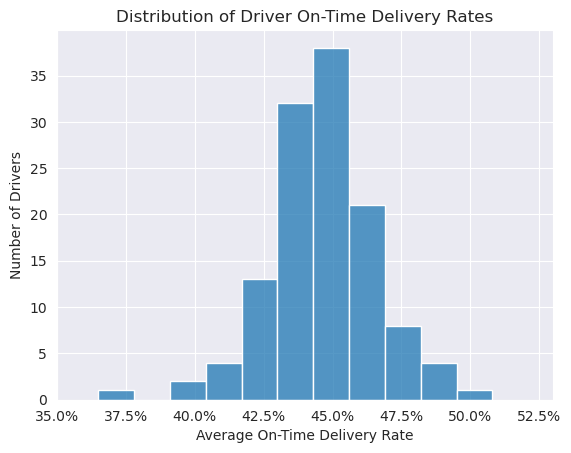

In [4]:
sns.histplot(
    data=df_on_time_rate_analysis,
    x="avg_on_time_rate",
    bins=11
)

plt.xlabel("Average On-Time Delivery Rate")
plt.ylabel("Number of Drivers")
plt.title("Distribution of Driver On-Time Delivery Rates")

plt.gca().xaxis.set_major_formatter(
    mtick.PercentFormatter(1)
)

plt.xlim(.35, .53)

## Net Revenue by Route Analysis
The next thing that I set out to analyze was just how much money was each route actually generating. The database keeps track of how much revenue each route is bringing in, but it does not actually keep track of the net revenue.

In [5]:
query="""
    WITH fuel_costs AS (
        SELECT
            t.load_id,
            SUM(fp.total_cost) AS fuel_cost
        FROM trips t
        LEFT JOIN fuel_purchases fp
            ON t.trip_id = fp.trip_id
        WHERE fp.total_cost IS NOT NULL
        GROUP BY t.load_id
    )
    
    SELECT
        l.route_id,
        ROUND(
            SUM(l.revenue)
            + SUM(l.fuel_surcharge)
            - SUM(fc.fuel_cost),
            2
        ) AS net_revenue
    FROM loads l
    LEFT JOIN fuel_costs fc
        ON l.load_id = fc.load_id
    GROUP BY l.route_id
    ORDER BY net_revenue ASC;
"""

df_net_revenue_analysis = pd.read_sql(query, conn)

df_net_revenue_analysis.head()

,route_id,net_revenue
0,RTE00010,-1400996.48
1,RTE00015,-1367427.06
2,RTE00033,-1002887.79
3,RTE00036,-520658.04
4,RTE00011,-98576.69


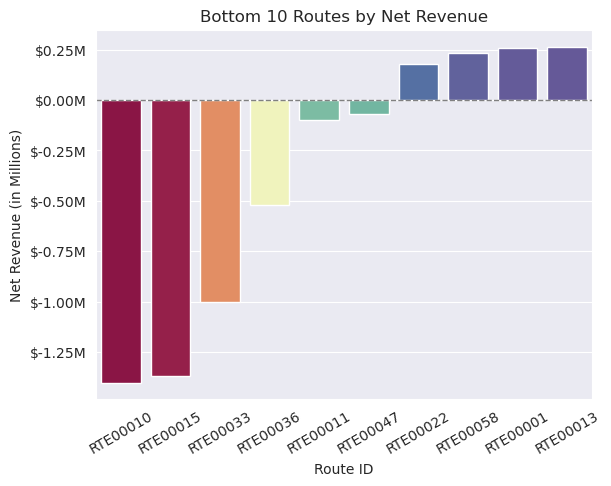

In [6]:
bottom_10 = df_net_revenue_analysis.head(10)

sns.barplot(
    data=bottom_10,
    x="route_id",
    y="net_revenue",
    hue="net_revenue",
    legend=False,
    palette=sns.color_palette("Spectral", as_cmap=True)
)

plt.axhline(0, linewidth=1, color="gray", linestyle="--")
plt.xticks(rotation=30)

plt.xlabel("Route ID")
plt.ylabel("Net Revenue (in Millions)")
plt.title("Bottom 10 Routes by Net Revenue")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1_000_000:.2f}M')
)

# Results
Upon doing an analysis of net revenue per route we notice that there are quite a few routes that are actually running at a loss for the company. This net revenue analysis does not even take into account the labor costs and there are a few routes that are still not earning that much either when compare to other routes.

Since there are so many routes that are losing money it is important to see why that is the case. I will next do some analyses on all the routes to figure out why some are losing money and why some are not.

## Route Revenue Analysis
During this portion the goal is to get a clearer picture of why exactly some routes are losing money and why some are fine.

In [6]:
query="""
    WITH fuel_costs AS (
        SELECT
            t.load_id,
            SUM(fp.total_cost) AS fuel_cost
        FROM trips t
        LEFT JOIN fuel_purchases fp
            ON t.trip_id = fp.trip_id
        GROUP BY t.load_id
    ),
    total_miles AS (
        SELECT
            l.route_id,
            SUM(t.actual_distance_miles)
            	AS total_miles_travelled,
            ROUND(AVG(t.actual_distance_miles),2)
            	AS avg_miles_travelled_per_trip
        FROM loads l
        LEFT JOIN trips t
            ON l.load_id = t.load_id
        GROUP BY l.route_id
    ),
    route_net_revenue AS (
        SELECT
            l.route_id,
            ROUND(
                SUM(l.revenue)
                + SUM(l.fuel_surcharge)
                - SUM(fc.fuel_cost),
                2
            ) AS net_revenue,
            tm.total_miles_travelled,
            tm.avg_miles_travelled_per_trip
        FROM loads l
        LEFT JOIN fuel_costs fc
            ON l.load_id = fc.load_id
        LEFT JOIN total_miles tm
            ON l.route_id = tm.route_id
        GROUP BY l.route_id
    )
    
    SELECT
        route_id,
        net_revenue,
        total_miles_travelled,
        avg_miles_travelled_per_trip,
        ROUND(net_revenue / total_miles_travelled, 2) AS net_revenue_per_mile
    FROM route_net_revenue
    ORDER BY net_revenue_per_mile ASC;
"""

df_route_revenue_analysis = pd.read_sql(query, conn)
df_route_revenue_analysis.head()

,route_id,net_revenue,total_miles_travelled,avg_miles_travelled_per_trip,net_revenue_per_mile
0,RTE00010,-1400996.48,138291,94.20,-10.13
1,RTE00015,-1367427.06,144882,94.26,-9.44
2,RTE00033,-1002887.79,255668,171.47,-3.92
3,RTE00036,-520658.04,410033,269.40,-1.27
4,RTE00011,-98576.69,844360,562.53,-0.12


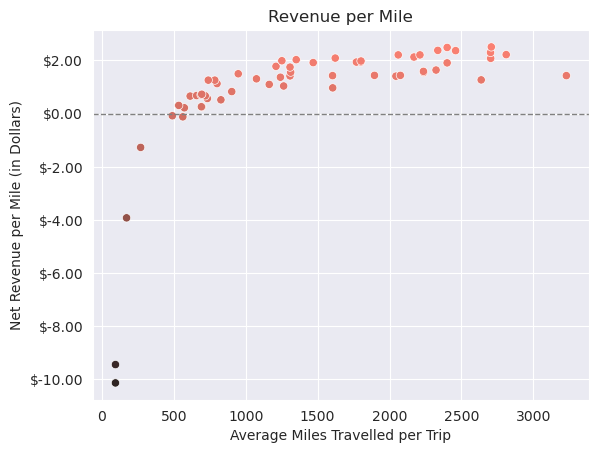

In [7]:
sns.scatterplot(
    data=df_route_revenue_analysis,
    x="avg_miles_travelled_per_trip",
    y="net_revenue_per_mile",
    hue="net_revenue_per_mile",
    legend=False,
    palette=sns.color_palette("dark:salmon", as_cmap=True)
)

plt.axhline(0, linewidth=1, color="gray", linestyle="--")

plt.xlabel("Average Miles Travelled per Trip")
plt.ylabel("Net Revenue per Mile (in Dollars)")
plt.title("Revenue per Mile")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x:.2f}')
)

## Results
First I wanted to set out to see if the distance of the trip/delivery had any sort of correlation with the revenue. We can see that: essentially once a delivery is less than 1k miles the profitability decreases, there is a cluster of breaking even around 500 miles, and losses with anything below 500 miles for a delivery. This is going to require a little more analysis to get a clearer image of what is going on and to be able to suggest any changes in order to improve the situation.

# Fuel Coverage Analysis
For this portion I wanted to see if the fuel surcharges could perhaps be the issue. In shorter routes perhaps we are not charging the customers enough to make up for the fuel actually used on the trip. So that is what I next set out to do.

In [7]:
query = """
    WITH fuel_costs AS (
        SELECT
            t.load_id,
            SUM(fp.total_cost) AS fuel_cost
        FROM trips t
        LEFT JOIN fuel_purchases fp
            ON t.trip_id = fp.trip_id
        GROUP BY t.load_id
    ),
    total_miles AS (
        SELECT
            l.route_id,
            SUM(t.actual_distance_miles) AS total_miles_travelled,
            ROUND(AVG(t.actual_distance_miles), 2) AS avg_miles_travelled_per_trip
        FROM loads l
        LEFT JOIN trips t
            ON l.load_id = t.load_id
        GROUP BY l.route_id
    ),
    route_surcharge_coverage AS (
        SELECT
            l.route_id,
            ROUND(SUM(l.fuel_surcharge), 2) AS total_surcharge,
            ROUND(SUM(fc.fuel_cost), 2) AS total_fuel_cost,
            tm.avg_miles_travelled_per_trip
        FROM loads l
        LEFT JOIN fuel_costs fc
            ON l.load_id = fc.load_id
        LEFT JOIN total_miles tm
            ON l.route_id = tm.route_id
        GROUP BY l.route_id
    )
    
    SELECT
        route_id,
        total_surcharge,
        total_fuel_cost,
        avg_miles_travelled_per_trip,
        ROUND(total_surcharge - total_fuel_cost, 2) AS coverage_gap,
        ROUND(total_surcharge / NULLIF(total_fuel_cost, 0), 3) AS coverage_ratio
    FROM route_surcharge_coverage
    ORDER BY coverage_ratio ASC;
"""

df_fuel_coverage_analysis = pd.read_sql(query, conn)
df_fuel_coverage_analysis.head()

,route_id,total_surcharge,total_fuel_cost,avg_miles_travelled_per_trip,coverage_gap,coverage_ratio
0,RTE00015,21210.60,1782066.61,94.26,-1760856.01,0.012
1,RTE00010,22959.52,1641529.05,94.20,-1618569.53,0.014
2,RTE00033,59759.28,1662837.92,171.47,-1603078.64,0.036
3,RTE00047,123988.48,1786126.58,489.86,-1662138.10,0.069
4,RTE00036,131592.12,1699724.63,269.40,-1568132.51,0.077


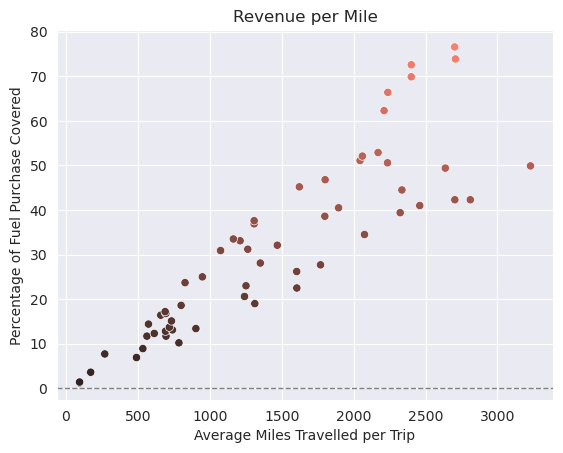

In [18]:
sns.scatterplot(
    data=df_fuel_coverage_analysis,
    x="avg_miles_travelled_per_trip",
    y="coverage_ratio",
    hue="coverage_ratio",
    legend=False,
    palette=sns.color_palette("dark:salmon", as_cmap=True)
)

plt.axhline(0, linewidth=1, color="gray", linestyle="--")

plt.xlabel("Average Miles Travelled per Trip")
plt.ylabel("Percentage of Fuel Purchase Covered")
plt.title("Revenue per Mile")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x*100:.0f}')
)

# Results
Based off our finding we can see that none of the trips actually charge enough for the surcharge.